# Week 3：電氣量測與ADC基礎

日期：2026-09-23

本週延續Week 2已完成的板卡、Upload、Serial、GPIO4按鈕輸入與GPIO5輸出命令，
開始回答一個新的問題：**我們看到的程式狀態或電表數字，如何成為可以支持判斷的
實體證據？**

共同實驗只使用散裝電阻、ESP32電源腳、GPIO5測試輸出與KY-018原始類比訊號。
DHT11、光線門檻、感測有效／無效分類與兩種感測器整合留到Week 4。

> **GPIO profile安全閘門**：本頁兩支程式目前以`-1`表示尚未公布的腳位。上課前
> 由教師依`docs/hardware_state.md`公布已通過實測的`PIN_TEST_OUTPUT`與`PIN_LIGHT`。
> 沒有正式值時只做閱讀與Verify，不Upload、不接模組，也不自行猜腳位。


## 一、Unit Overview

### Teaching Objectives

By the end of this unit, students will be able to:

1. Select an appropriate multimeter function and range, and record resistance or DC
   voltage with measurement points and units.
2. Explain voltage, current, resistance, ground, a closed circuit, and a short circuit
   using the circuits measured in this unit.
3. Measure 3V3, 5Vin, GPIO LOW, GPIO HIGH, and the post-reset startup state relative
   to GND.
4. Distinguish a software output command from physical voltage evidence.
5. Identify the power, ground, and signal pins of the course KY-018 module before
   applying power.
6. Collect repeated ADC raw readings under controlled lighting conditions and state
   what those readings can and cannot prove.
7. Support a measurement conclusion with the operating condition, meter range,
   measurement points, value, unit, repeated evidence, and an explicit limitation.

### Teaching Content

This unit develops electrical measurement as an evidence-building process. Students
will connect voltage, current, resistance, ground, closed circuits, and short circuits
to observations made with their own multimeter. They will measure loose resistors,
establish separate ground and power test points, compare nominal 3V3 and 5Vin labels
with measured voltages, and verify that GPIO software states correspond to physical
LOW and HIGH voltages. They will then use a KY-018 photoresistor module as a changing
analog source, compare signal voltage with 12-bit ADC raw readings, and collect repeated
data without prematurely treating the readings as volts, lux, or calibrated light
states. The closing discussion asks students to decide when a number is sufficient
evidence for a technical claim.

### 核心實驗流程

| 階段 | 開始前狀態 | 操作 | 完成條件 |
|---|---|---|---|
| A. 電表準備 | 電表未接電路 | 分辨插孔、功能與量程 | 能說出目前要量什麼及為何選此檔位 |
| B. 散裝電阻 | ESP32與所有電源均斷開 | 量220Ω、1kΩ與10kΩ | 每筆都有量程、數值與單位 |
| C. 電源測試點 | USB拔除 | 建立PGND、P3V3與P5V並查低阻抗錯接 | 三個測試點可追溯且彼此未持續蜂鳴 |
| D. 電源電壓 | 測試點通過斷電檢查 | 量3V3與5Vin相對GND | 兩筆都有測點、正負號、數值與V |
| E. GPIO電壓 | GPIO5不接負載 | 自動切換LOW／HIGH並在Reset後重測 | LOW、HIGH與Reset後狀態都有電表證據 |
| F. KY-018原始值 | USB拔除且模組腳位已辨認 | 量訊號電壓並讀取ADC raw | 三種光線各有重複數據與控制條件 |
| G. Discussion | 保留全部原始紀錄 | 比較命令、電壓與ADC證據 | 結論引用數值、條件並說明限制 |


## 二、器材、分組與前置條件

| 品項 | 數量 | 本週用途 |
|---|---:|---|
| YD-ESP32-S3 Type-A V1.5／ESP32-S3-WROOM-1 N16R8 | 1 | 電源腳、GPIO與ADC |
| 400孔麵包板 | 1 | 建立分開的量測點與共用接點 |
| 公對母、公對公及母對母杜邦線 | 各數條 | 依端點形式完成連線 |
| 220Ω、1kΩ、10kΩ散裝電阻 | 各1顆 | 電阻量程與數量級比較 |
| KY-018光敏電阻模組 | 1 | 可隨光線改變的類比訊號 |
| 具通斷、電阻及低壓直流電壓功能的數位萬用電表 | 每組1台 | 斷電檢查與上電量測 |
| USB資料線與已完成Week 2設定的筆電 | 各1 | 供電、Upload與Serial |
| 手機手電筒或固定光源 | 1 | 建立可重做的亮光條件 |

每組1～3人。每組使用自己的萬用電表；1人組可向其他組共用，但兩組必須分開
保存數值、照片與判讀。操作電表者、固定表筆者及記錄者可以輪替，任何人都必須
能說明黑表筆、紅表筆、檔位與測點的作用。

本週不使用DHT11、RGB、蜂鳴器、SG90、4AA電池盒或網路功能。

進入條件：能完成Week 2的Verify、Upload與115200-baud Serial Monitor；知道改線、
通斷與電阻量測前先拔除ESP32端USB。若這些條件尚未成立，先回到
[Week 2教材](../Week_02_ESP32_Hardware_Basics/week2_main.ipynb)。

| Profile名稱 | 本頁目前值 | 上課時可使用的來源 |
|---|---:|---|
| `PIN_TEST_OUTPUT` | `-1` | 教師公布的指定板卡實測紀錄 |
| `PIN_LIGHT` | `-1` | 教師公布的指定板卡ADC實測紀錄 |

### 本課參考電表

下圖是教師現有A830L。不同品牌的旋鈕位置可能不同，因此辨認時以功能符號與單位
為準，不照抄旋鈕方向。

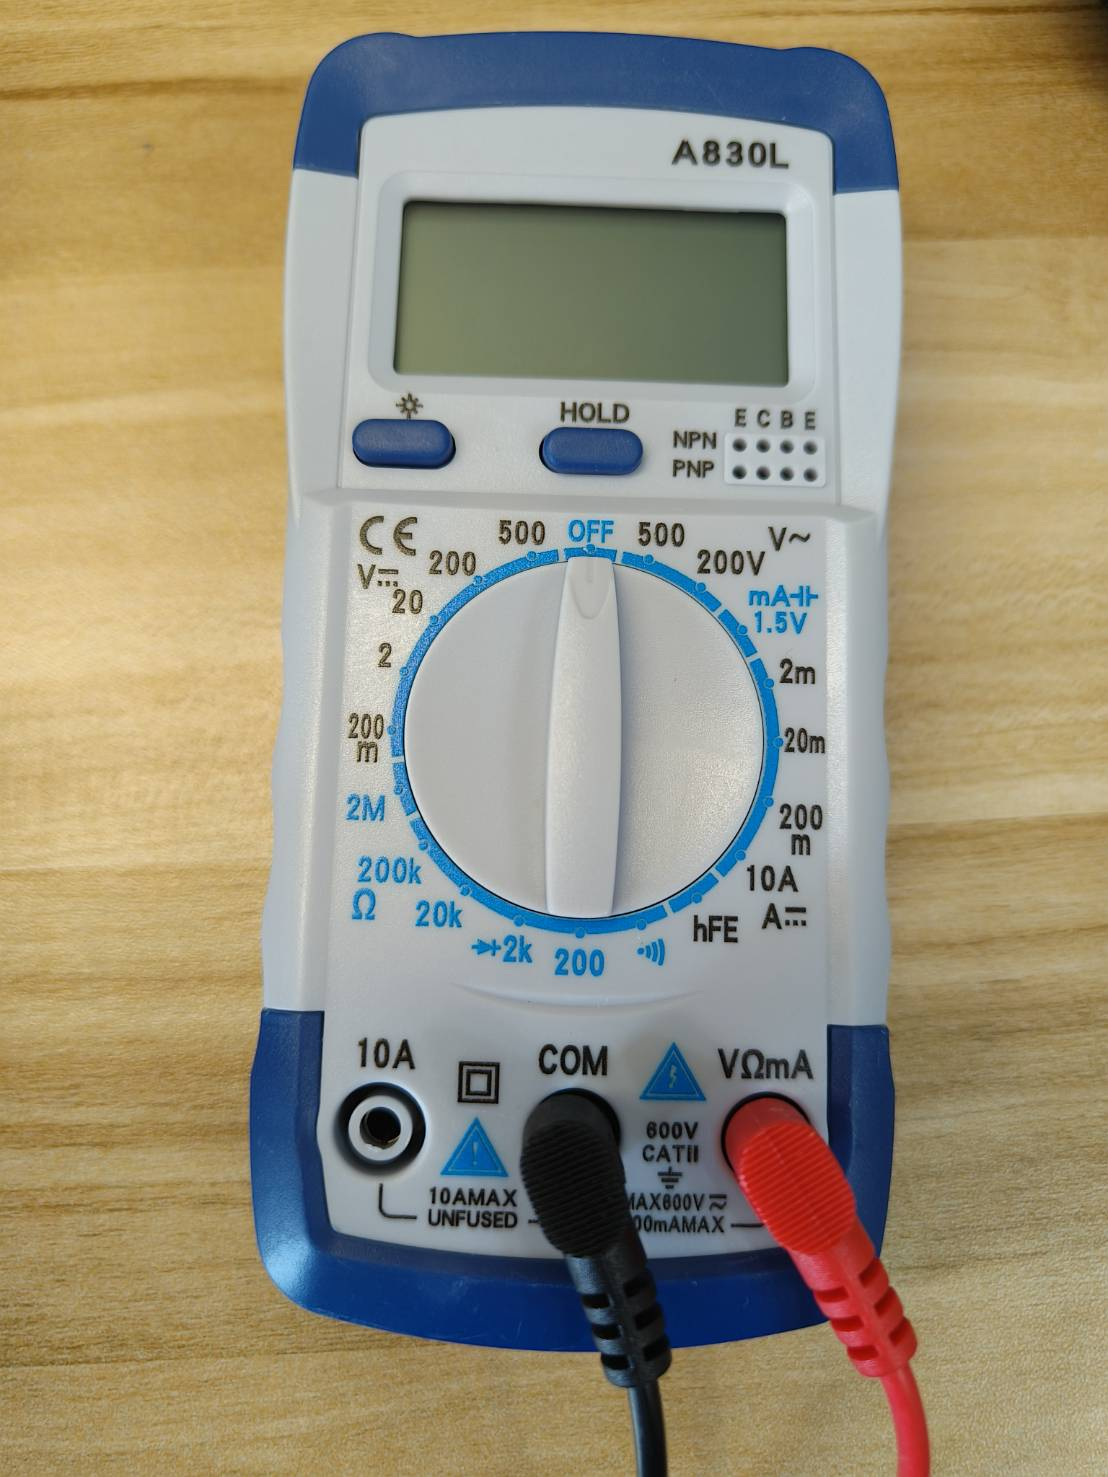


## 三、安全規則：先決定量什麼，再碰電路

### 三種量測不可混用

| 要量的量 | 電路是否供電 | 黑表筆 | 紅表筆 | 本週使用功能 |
|---|---|---|---|---|
| 通不通 | 完全斷電 | `COM` | `VΩmA` | 通斷蜂鳴／continuity |
| 電阻多大 | 完全斷電 | `COM` | `VΩmA` | `Ω`及合適量程 |
| 兩點電壓差 | 必須上電 | `COM` | `VΩmA` | 直流電壓`V⎓ 20` |

本週**不量電流**，紅表筆不插`10A`孔，也不把旋鈕轉到`A⎓`或mA檔。電流檔內部
阻抗很低；如果像量電壓一樣把兩支表筆跨接在3V3與GND，電表本身可能形成短路。
照片上的`10A`是電流插孔與上限標示，不是`10V`。

### 改線前的固定順序

1. 關閉Serial Monitor只會停止畫面，不會切斷USB電力。
2. 從ESP32端拔除USB。
3. 確認`PWR`燈熄滅。
4. 電表轉到`OFF`並移開表筆。
5. 才能插、拔或移動任何杜邦線、模組或電阻。

直流電壓量測必須上電時，黑表筆固定在GND測試點，紅表筆一次只碰一個目標點。
表筆尖端若可能滑到相鄰腳位，立即移開並重新固定，不勉強量測。


## 四、從實物理解電壓、電流、電阻與GND

### 電壓`V`：推動電荷移動的兩點差異

`V`代表volt（伏特）。電表量到的不是「某一點自己有多少電壓」，而是紅表筆位置
相對黑表筆位置的電位差。本週把黑表筆放在GND，所以`3.3 V`的完整意思是：

> 紅表筆所在的3V3測試點，比黑表筆所在的GND測試點高約3.3 V。

USB提供約5 V給開發板，板上的穩壓電路再建立約3.3 V供ESP32邏輯使用。`5Vin`與
`3V3`因此是不同電源節點；名稱是預期功能，仍要用電表確認實物。

### 電流`I`：每段時間通過路徑的電荷量

傳統電流方向由較高電位流向較低電位。電流要持續存在，必須有**封閉迴路**：從
電源出發，經過元件，再回到電源參考端。缺少回程路徑時，電荷無法沿完整路徑持續
移動。因此GND不是「可有可無的負號」，而是本電路的共同參考與回程節點。

### 電阻`R`：限制電流的程度

`Ω`代表ohm（歐姆）。歐姆定律`V = I × R`可改寫成`I = V / R`：同一電壓下，
電阻越小，電流越大。例如只作理論比較時，3.3 V加在1 kΩ上，理想電流約為
`3.3 V / 1000 Ω = 0.0033 A = 3.3 mA`。若路徑接近0 Ω，理想公式會要求非常大的
電流；實際電流雖受USB、穩壓器、導線與晶片限制，仍可能造成過熱、重啟或損壞。

**流量大不一定好。** 致動器需要足夠電流才能工作，但導線、GPIO與元件都有安全
上限。設計目標是讓電流走預定路徑並保持在元件可承受範圍，而不是越大越好。

### 短路：不該存在的低阻抗路徑

短路是電源與回程之間出現意外的低阻抗路徑，使電流繞過原本要控制或保護的元件。
「兩個獨立測試點沒有蜂鳴」只表示電表目前沒有量到低阻抗連接；「兩點持續蜂鳴」
也不一定立刻代表危險，因為它們可能原本就應相連。判斷短路必須先知道這兩點在
設計上是否應導通。

### 紅、藍線與正負號只是標示

紅色杜邦線不會自己產生正電，藍色線也不會自己產生負電。麵包板紅色`+`與藍色
`−`只是方便辨認的印刷線；只有接上3V3或GND後，該列才具有對應電氣功能。GND在
本課通常作0 V參考，但它不是宇宙中的絕對零電位，也不表示所有地方都帶「負電」。


## 五、讀懂A830L的插孔、顏色、符號與數字

### 插孔

- 黑表筆固定插`COM`。`COM`是common（共同參考端），本週量電壓時接GND。
- 紅表筆固定插`VΩmA`。本週的通斷、電阻與直流電壓都使用這個插孔。
- `10A`孔保持空置；它沒有保險絲保護的標示，且本週不量電流。

### 藍色與黑色印刷不代表正負電

A830L面板用藍色與黑色協助區分印刷區域，但這不是所有電表共用的標準，也不表示
正電與負電。必須看`V⎓`、`V~`、`Ω`、蜂鳴符號、`A⎓`及數值單位決定功能。

### `200`、`2k`與`20k`是量程

旋鈕在`Ω 200`時，`200`表示這個檔位用來顯示約200 Ω以內的電阻，不是電表會送出
200 Ω，也不是固定答案。`2k`與`20k`分別是約2,000 Ω與20,000 Ω的量程。

量程太低時，A830L可能在最左側顯示固定的`1`，表示超出目前量程或開路；這不是
1 Ω。量程合適且兩表筆尖端直接接觸時，常見讀值是`0.x Ω`，包含表筆、接觸與導線
電阻，不必恰好是0.0 Ω。

### 通斷測試是正式技術用語

continuity test通常翻成**通斷測試**或**導通測試**。蜂鳴表示電表判定兩點之間的
電阻低於該機型的蜂鳴門檻；門檻不是0 Ω，也不是所有電表都相同。因此曾看到
30～80 Ω或198 Ω時，不能只靠有沒有聲音推定精確電阻，應切到Ω檔並確認量程、
接觸方式與顯示單位。


## 六、實驗一：量測三種散裝電阻

開始前：ESP32端USB已拔除，桌上沒有電池或其他電源；黑表筆在`COM`，紅表筆在
`VΩmA`。

1. 將220Ω、1kΩ與10kΩ分開放置，保留原包裝或分裝標籤。標籤是本次標稱值來源；
   色環可作辨認練習，但不能取代實測。
2. 先讓兩支表筆尖端相碰，記錄表筆短接值。正常時應接近0 Ω；若持續顯示固定`1`，
   先檢查插孔、旋鈕與表筆，不量電阻。
3. 量220Ω：旋鈕先轉`Ω 2k`，兩支表筆分別碰電阻兩端，等數值穩定後記錄。
4. 量1kΩ：保持`Ω 2k`先試量。若顯示超量程，再轉`20k`後重測。
5. 量10kΩ：轉`Ω 20k`後量測。
6. 每次只碰電阻的一端；不要同時用兩手捏住兩端金屬腳，人體可能形成並聯路徑，
   尤其量較大電阻時會改變結果。
7. 依旋鈕量程判讀小數點與單位。不同電表可能在`2k`檔顯示`998`或以kΩ形式顯示
   `0.998`；先查該表的量程標示，再記為約`998 Ω`，不要只抄沒有單位的數字。

| 標稱值 | 使用量程 | 畫面數字 | 換算後數值與單位 | 與表筆短接值的差異 | 判讀 |
|---:|---|---:|---:|---:|---|
| 220Ω |  |  |  |  |  |
| 1kΩ |  |  |  |  |  |
| 10kΩ |  |  |  |  |  |

完成條件：三筆都有量程、畫面、換算值與單位，且能說明為什麼它們的數量級不同。
實測不必恰好等於標稱值。完成後把旋鈕轉`OFF`。


## 七、實驗二：建立PGND、P3V3、P5V與TPO

這四個名稱是本實驗自訂的test point（測試點）標籤，不是麵包板原廠功能：

- `PGND`：接到ESP32實物絲印`GND`，作黑表筆共同參考。
- `P3V3`：接到實物絲印`3V3`。
- `P5V`：只在清楚看見本批板上的`5Vin`／`5VIN`絲印後連接。
- `TPO`：接到教師正式公布的GPIO測試輸出。

### 步驟1：斷電建立測試點

1. USB保持拔除，`PWR`燈熄滅，電表轉`OFF`。
2. 在麵包板選四個彼此分開、沒有跨越中央溝槽的五孔組，貼上四個標籤並寫下座標。
3. 使用公對母線分別把ESP32 `GND`、`3V3`、`5Vin`與profile指定的GPIO測試輸出腳接到對應測試點。
4. 每接一條線，就用手指從ESP32絲印沿線走到測試點，再反向走一次。
5. `5Vin`文字不清楚時停止，不以「靠近USB的腳」猜測。

### 步驟2：斷電通斷檢查

1. 電表轉到通斷檔，先碰兩表筆確認蜂鳴器能工作。
2. 逐條確認`ESP32腳位 ↔ 對應測試點`有蜂鳴。
3. 再檢查`PGND ↔ P3V3`、`PGND ↔ P5V`、`PGND ↔ TPO`、`P3V3 ↔ P5V`。
4. 這些不同功能測試點不應出現**持續**蜂鳴或穩定接近0 Ω。接到板上電容時可能有
   短暫聲音後消失；先等顯示穩定。若持續蜂鳴，保持斷電並逐線拆查。
5. 通過後將旋鈕轉回`OFF`並移開表筆。

這一步只能排除目前量得到的低阻抗錯接，不能證明P3V3真的有3.3 V、TPO真的能
輸出HIGH，也不能證明上電後一定安全；下一個實驗才量電壓。


## 八、實驗三：量測3V3與5Vin

### 步驟1：選擇直流電壓功能

1. 黑表筆仍在`COM`，紅表筆仍在`VΩmA`。
2. 旋鈕轉到直流電壓`V⎓ 20`。`20`表示量程約20 V，不表示電表會送出20 V。
3. 黑表筆固定在`PGND`；先不要讓紅表筆碰任何位置。

### 步驟2：上電與安全觀察

1. 接回板背標示`COM`的USB接頭。
2. 觀察`PWR`是否亮起，並在前五秒確認沒有異常發熱、煙、焦味或聲音。
3. 有異常立即拔除ESP32端USB；沒有異常才開始量測。

### 步驟3：取得兩筆完整電壓證據

1. 紅表筆只碰`P3V3`，等讀值穩定，記錄正負號、數值與`V`。
2. 移開紅表筆，再只碰`P5V`，記錄第二筆。
3. `P3V3`通常接近3.3 V；USB供電時`P5V`通常接近5 V。線材、USB供電及儀表誤差
   會讓讀值不同，應保存實測值，不把預期值抄進結果欄。
4. 若出現負號，先移開紅表筆，再核對黑表筆是否真的在PGND；負號通常表示表筆
   參考方向相反，不是板子產生「危險的負電」。
5. 若讀值接近0 V、兩者幾乎相同或明顯偏離預期，先移開表筆並拔USB，才追查接線。

完整紀錄範例的句型是：

> USB供電、A830L使用`V⎓ 20`檔，黑表筆在PGND、紅表筆在P3V3，實測為____ V。

這個句子同時交代條件、儀表功能、參考點、目標點、數值與單位。完成後先移開紅
表筆，再移開黑表筆，最後拔除USB並把電表轉`OFF`。


In [ ]:
// Fill in only the GPIO value published in the verified course hardware profile.
// Keep -1 when no verified profile is available.
const int PIN_TEST_OUTPUT = -1;
const unsigned long PHASE_DURATION_MS = 10000;

bool outputHigh = false;
unsigned long phaseStartedMs = 0;
unsigned long cycleNumber = 1;

bool profileReady() {
  return PIN_TEST_OUTPUT >= 0;
}

void reportPhase() {
  Serial.printf(
    "cycle=%lu phase=%s expected_voltage=%s measure_now=true\n",
    cycleNumber,
    outputHigh ? "HIGH" : "LOW",
    outputHigh ? "near_3.3V" : "near_0V"
  );
}

void setup() {
  Serial.begin(115200);
  delay(500);

  if (!profileReady()) {
    Serial.println("week=3 status=blocked reason=gpio_profile_missing");
    return;
  }

  pinMode(PIN_TEST_OUTPUT, OUTPUT);
  digitalWrite(PIN_TEST_OUTPUT, LOW);
  outputHigh = false;
  phaseStartedMs = millis();

  Serial.printf(
    "week=3 pin_test_output=%d startup=LOW phase_duration_ms=%lu\n",
    PIN_TEST_OUTPUT,
    PHASE_DURATION_MS
  );
  reportPhase();
}

void loop() {
  if (!profileReady()) return;

  unsigned long now = millis();
  if (now - phaseStartedMs < PHASE_DURATION_MS) return;

  phaseStartedMs = now;
  outputHigh = !outputHigh;
  digitalWrite(PIN_TEST_OUTPUT, outputHigh ? HIGH : LOW);
  if (!outputHigh) cycleNumber++;
  reportPhase();
}


## 九、實驗四：用電表驗證GPIO5的LOW、HIGH與Reset後狀態

上方程式每10秒自動切換一次輸出，避免單人同時拿表筆與按按鈕。`TPO`只接電表，
不接LED、蜂鳴器、舵機或其他負載。

### 先讀懂程式

- `PIN_TEST_OUTPUT`是方便閱讀的名稱；正式profile未通過前保持`-1`。
- `profileReady()`阻止未設定腳位時啟用硬體。
- `pinMode(..., OUTPUT)`把指定GPIO設為數位輸出。
- `digitalWrite(..., LOW/HIGH)`命令輸出邏輯LOW或HIGH；這是軟體命令，仍要電表證明
  實體電壓。
- `PHASE_DURATION_MS=10000`代表每個狀態維持10,000 ms，也就是10秒。
- `millis()`取得開機後經過的毫秒數；程式用時間差切換，不用長時間`delay()`阻塞。
- `expected_voltage`是程式寫出的預期文字，不是測量結果。

### 步驟1：準備與上傳

1. USB保持拔除，以通斷檔重查`profile指定的GPIO測試輸出腳 ↔ TPO`導通，以及`TPO ↔ PGND`不持續
   蜂鳴；完成後電表轉`OFF`。
2. 開啟[`week03_gpio_voltage_cycle.ino`](../../examples/week03_gpio_voltage_cycle/week03_gpio_voltage_cycle.ino)。
3. 將`PIN_TEST_OUTPUT=-1`改成教師正式公布的profile值；未公布時保持`-1`。
4. Verify。編譯成功只證明程式與工具鏈通過，不證明GPIO電壓。
5. Upload後開啟115200-baud Serial Monitor。應依序看到`startup=LOW`、`phase=LOW`，
   約10秒後看到`phase=HIGH`。

### 步驟2：量測LOW與HIGH

1. 電表轉`V⎓ 20`，黑表筆固定在PGND，紅表筆固定在TPO。
2. Serial顯示`phase=LOW`時记录一次；正常應接近0 V。
3. Serial顯示`phase=HIGH`時记录一次；正常應接近3.3 V。
4. 重複直到LOW與HIGH各有三筆。每一筆都要同時抄下cycle、phase及電表值。
5. 若Serial與電壓不一致，先移開紅表筆並拔USB，再核對TPO、PGND、程式與profile。

### 步驟3：Reset後重新確認安全命令

1. 等到`phase=HIGH`並記錄一筆後，移開紅表筆。
2. 短按板上`RST`，等待Serial重新出現`startup=LOW`與`phase=LOW`。
3. 再把紅表筆放回TPO，記錄Reset後讀值。

這個結果只證明程式重新進入`setup()`後已命令LOW，**不能證明Reset到`setup()`之間
從未出現短暫脈衝**。要主張整個啟動瞬間都安全，需要示波器或邏輯分析儀等更高
時間解析度的證據；本週不作這項主張。

完成條件：LOW三筆、HIGH三筆與Reset後一筆都有phase、測點、檔位、數值與單位；
能說明Serial是命令證據，電表是實體電壓證據。


## 十、辨認KY-018：先看實物，再決定能不能接線

KY-018上的photoresistor（光敏電阻）會隨光線改變電阻，模組把這個變化轉成訊號
電壓。ESP32的ADC會把訊號電壓轉成數字。

下列是本課教師實物照片。照片可用來辨認元件種類，但腳位仍以自己手上的絲印為準；
不可把照片左右位置或杜邦線顏色當作腳位證據。

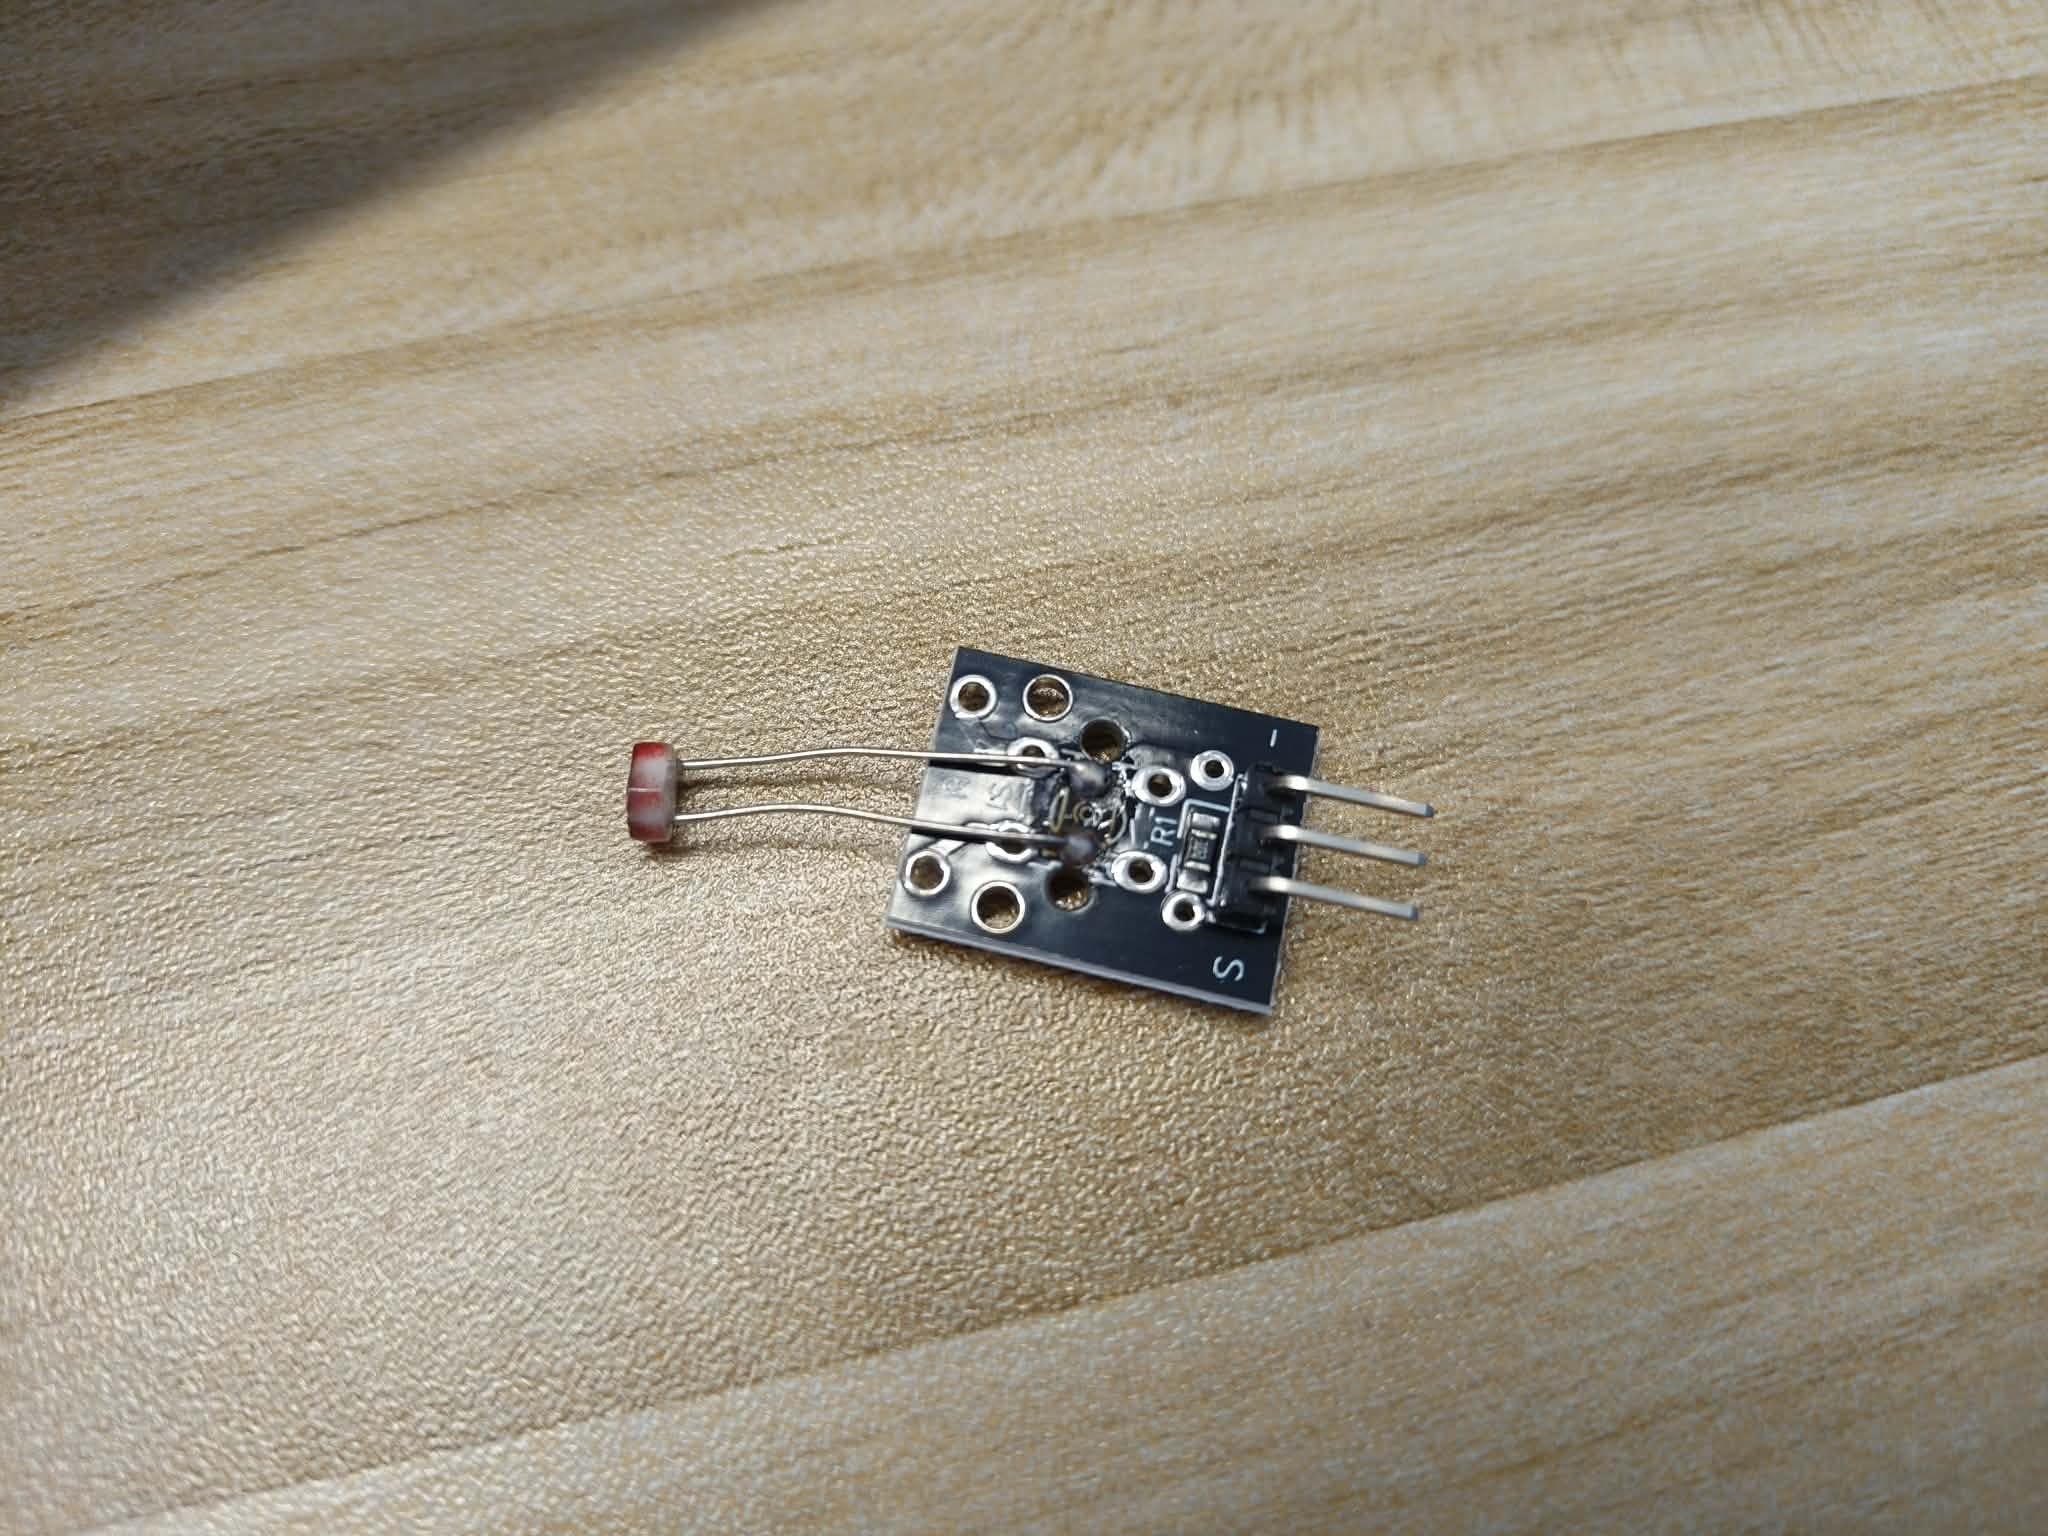

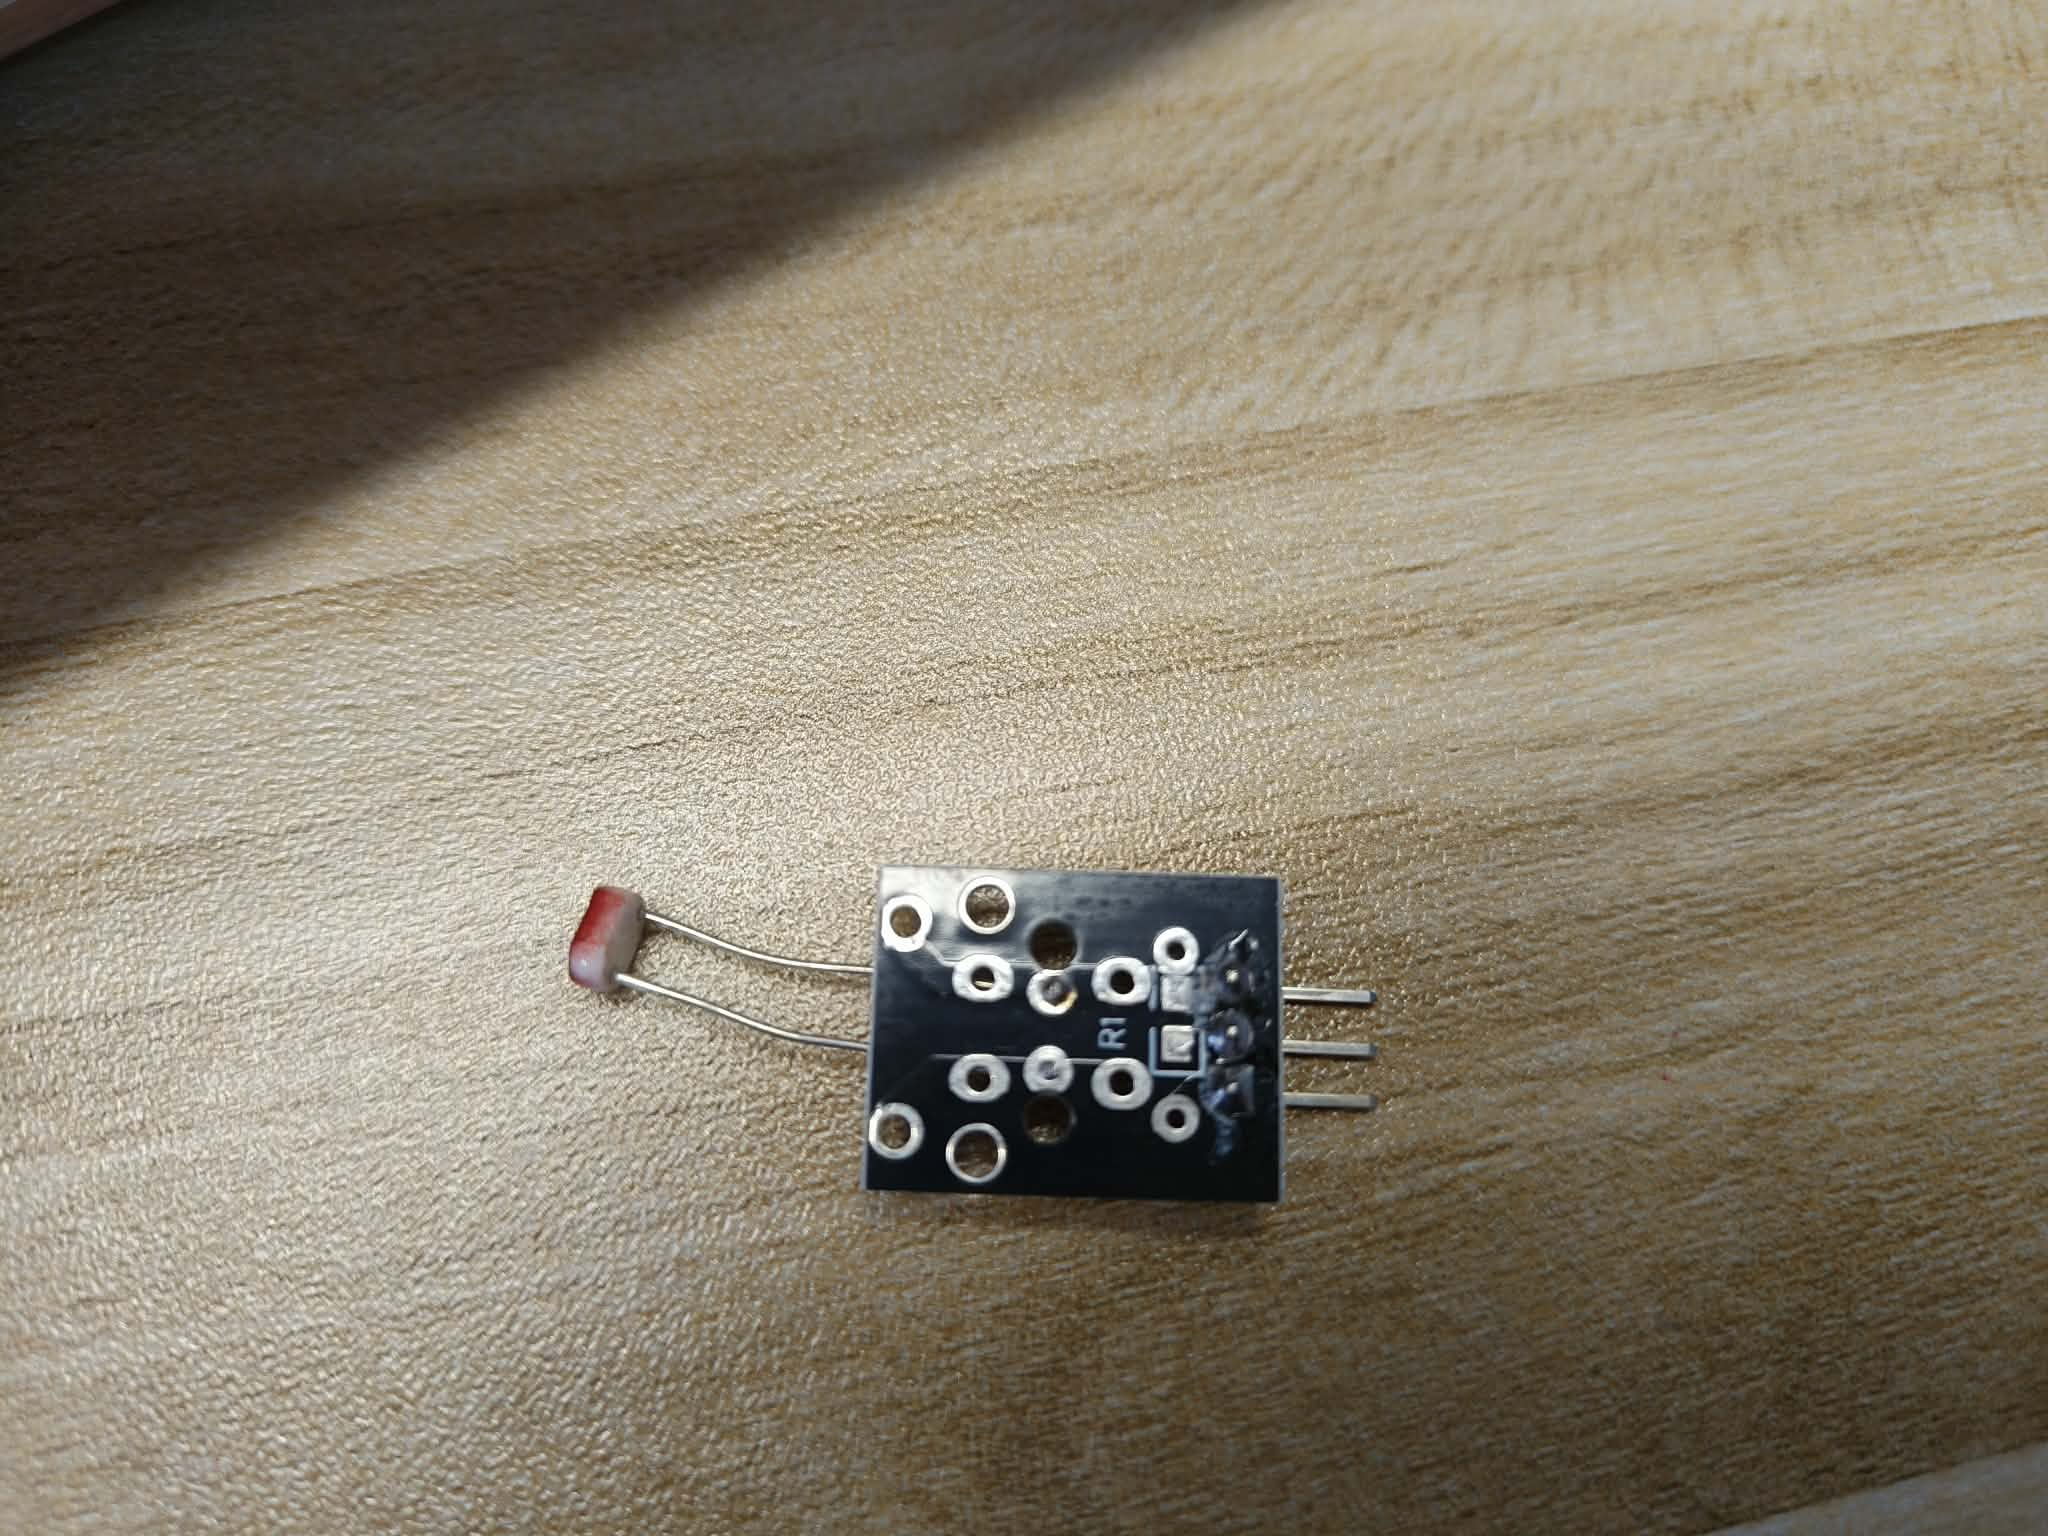

### 斷電辨認

1. 拔除USB並確認`PWR`熄滅。
2. 找到圓形或扁圓形、有蛇形紋路的光敏電阻。
3. 找到三根排針旁的絲印。常見功能為`S`（signal）、`+`（VCC）與`-`（GND），但
   自己的模組若標示不同，先記錄實物文字，不自行翻譯左右順序。
4. 拍一張同時看見元件與排針絲印的照片。
5. 任何一腳看不清楚時停止，補拍近照或交由教師確認；不靠網路購物圖猜測。

| 實物絲印 | 目前判定功能 | 之後連接到 | 證據 |
|---|---|---|---|
|  | 訊號 | 已驗證的`PIN_LIGHT` | 實物近照／教師profile |
|  | 電源 | P3V3 | 實物近照 |
|  | 參考地 | PGND | 實物近照 |


## 十一、ADC與原始值

ADC是Analog-to-Digital Converter（類比數位轉換器），把輸入電壓轉成程式可以
處理的數字。Espressif的Arduino-ESP32 ADC API說明：

- `analogRead(pin)`回傳未校準的raw value（原始值）。
- 預設12-bit解析度會產生0～4095的數字，共4096個階級。
- `ADC_11db`讓ESP32-S3可量測較高的輸入範圍；官方表列可量測範圍約到3100 mV。

因此`light_raw=2048`不是2048 V、2048 Ω或2048 lux，也不能直接寫成「50%亮」。
ADC、晶片差異與輸入接近上限時的飽和都會影響數字。KY-018訊號接近3.3 V時，raw
可能靠近4095；這時應同時看電表訊號電壓，而不是從4095反推出精確電壓。

ESP32-S3官方datasheet將GPIO4列為`ADC1_CH3`，但晶片具有某項功能不等於每一種
開發板都已完成相同接線與實測。學生只使用教師公布的本課profile，不把官方晶片
表格直接當成自己板卡已通過的證據。

### KY-018接線關係



1. USB保持拔除，P3V3與PGND是兩個分開的五孔組。
2. KY-018電源腳用公對母線接P3V3；P3V3另一條線回ESP32 `3V3`。
3. KY-018 GND腳用公對母線接PGND；PGND另一條線回ESP32 `GND`。
4. KY-018訊號腳用母對母線接教師正式公布的`PIN_LIGHT`。
5. 先依`訊號→GPIO4、VCC→P3V3→3V3、GND→PGND→GND`正向逐線檢查，再從ESP32
   反向檢查回模組。
6. 確認沒有任何線接5V，並拍攝可辨認模組絲印與ESP32腳位的俯視照。

接回USB後，先用電表`V⎓ 20`量KY-018訊號相對PGND的電壓。若讀值小於0 V、明顯
高於3.3 V或無法穩定接觸，移開紅表筆、拔USB並重新核對，不上傳ADC程式。


In [ ]:
// Fill in only the ADC GPIO published in the verified course hardware profile.
// Keep -1 when no verified profile is available.
const int PIN_LIGHT = -1;
const unsigned long SAMPLE_INTERVAL_MS = 500;
const char* DEVICE_ID = "CHANGE_ME";

unsigned long lastSampleMs = 0;
unsigned long sampleNumber = 0;

bool profileReady() {
  return PIN_LIGHT >= 0;
}

void setup() {
  Serial.begin(115200);
  delay(500);

  if (!profileReady()) {
    Serial.println("week=3 sensor=ky018 status=blocked reason=gpio_profile_missing");
    return;
  }

  analogReadResolution(12);
  analogSetPinAttenuation(PIN_LIGHT, ADC_11db);
  Serial.printf(
    "week=3 sensor=ky018 status=ready device=%s pin_light=%d "
    "adc_bits=12 interval_ms=%lu\n",
    DEVICE_ID,
    PIN_LIGHT,
    SAMPLE_INTERVAL_MS
  );
}

void loop() {
  if (!profileReady()) return;

  unsigned long now = millis();
  if (now - lastSampleMs < SAMPLE_INTERVAL_MS) return;
  lastSampleMs = now;
  sampleNumber++;

  int lightRaw = analogRead(PIN_LIGHT);
  Serial.printf(
    "device=%s sample=%lu uptime_ms=%lu light_raw=%d\n",
    DEVICE_ID,
    sampleNumber,
    now,
    lightRaw
  );
}


## 十二、實驗五：取得KY-018原始ADC資料

### 先讀懂程式

- `PIN_LIGHT`是KY-018訊號所接的ADC GPIO；正式profile未公布時保持`-1`。
- `DEVICE_ID`是資料來源代碼。把`CHANGE_ME`改成課堂指定的非個資代碼，不使用姓名
  或學號。
- `analogReadResolution(12)`將`analogRead()`輸出固定為12-bit的0～4095。
- `analogSetPinAttenuation(..., ADC_11db)`設定本次ADC輸入範圍；它不會把GPIO變成
  11 V耐壓腳，也不允許輸入超過3.3 V。
- `SAMPLE_INTERVAL_MS=500`表示每500 ms取一筆，也就是約每秒兩筆。
- 每行保留device、sample、uptime與light_raw，尚未加入DARK／NORMAL／BRIGHT分類、
  `valid`或`reason`；那些是Week 4校正後的內容。

### 步驟1：Verify、Upload與基準輸出

1. 開啟[`week03_ky018_raw.ino`](../../examples/week03_ky018_raw/week03_ky018_raw.ino)。
2. 將`PIN_LIGHT=-1`改成教師正式公布的profile值；未公布時保持`-1`。
3. 修改`DEVICE_ID`，儲存後Verify、Upload。
4. 開啟115200-baud Serial Monitor。正常開場格式為：

```text
week=3 sensor=ky018 status=ready device=<代碼> pin_light=<profile> adc_bits=12 interval_ms=500
```

5. 後續每行應約相隔500 ms：

```text
device=<代碼> sample=<遞增編號> uptime_ms=<遞增毫秒> light_raw=<0至4095實測值>
```

若只看到`gpio_profile_missing`，代表安全阻擋正常工作；不要用任意GPIO繞過。

### 步驟2：控制三種光線條件

每種條件都先固定，再量訊號電壓與保存10筆raw：

1. **遮光**：使用不導電、不碰排針的遮光物固定蓋住光敏元件。
2. **室內光**：移除遮光物，保持模組方向與桌面位置不變。
3. **亮光**：固定手機手電筒與元件的距離與角度，不把手機壓在線路上。

每種條件的操作順序：

1. 等待條件穩定2秒。
2. 電表黑表筆在PGND、紅表筆在KY-018訊號測試點，以`V⎓ 20`記錄一筆電壓。
3. 移開紅表筆，不改線，從Serial原封不動保存連續10筆raw。
4. 記錄最小值、最大值及變亮時raw上升或下降；本週不建立threshold。

如果raw永遠是0或4095，先看電表訊號電壓：若電壓也靠近範圍端點，可能是目前
光線與模組電路造成；若電壓會改變但raw完全不變，拔USB後核對訊號腳與profile。
不拔訊號線作故障注入，因為浮接ADC可能產生任意數字，無法形成單一可預測答案。

完成條件：三種光線各有條件描述、訊號電壓、10筆原始log與raw範圍；能說明raw
不是伏特或lux，也沒有提前建立光線分類。


## 十三、Week 3 Discussion：一個數字什麼時候能成為證據？

本週只討論這一個問題。所有回答都使用自己的量測與原始log，不把預期值當結果。

### 13.1 先建立完整量測句

一筆可檢查的電表證據至少包含：

> 供電與操作條件＋儀表功能／量程＋黑表筆位置＋紅表筆位置＋數值與單位

從自己的紀錄各選一筆電阻、P3V3與GPIO HIGH，改寫成完整句子。接著和另一組交換
閱讀；對方必須能只靠句子重建「量什麼、怎麼量、得到什麼」，否則補上缺少欄位。

### 13.2 比較「命令」與「實體結果」

使用GPIO實驗完成下表：

| 證據 | 它能支持什麼 | 它不能單獨支持什麼 |
|---|---|---|
| Serial顯示`phase=HIGH` |  |  |
| TPO相對PGND的HIGH電壓 |  |  |
| Reset後重新顯示`startup=LOW` |  |  |
| Reset後TPO的電表讀值 |  |  |

用兩項不同證據回答：GPIO5是否在程式進入`setup()`後依命令輸出LOW與HIGH？再說明
為什麼本實驗不能證明Reset瞬間完全沒有短脈衝。

### 13.3 比較電表電壓與ADC raw

1. 執行三種光線前，先預測變亮時KY-018訊號電壓與raw會上升、下降或不確定，並
   寫出理由。預測可以錯，但必須在看結果前保存。
2. 每種光線都固定模組位置、供電、光源距離與取樣筆數；只改光線條件。
3. 比較三筆訊號電壓與三組raw範圍。兩者是否呈相同方向？若不同，先檢查測點、
   時間與是否在相同光線下取得，不直接刪除異常資料。
4. 判斷三組raw是否可看出變化與重複性。即使範圍沒有重疊，本週也只建立基準，
   不把它寫成永久DARK／NORMAL／BRIGHT門檻。
5. 寫出至少兩項限制，例如只測一片板、一個KY-018、同一USB供電、同一室內光、
   ADC接近上限可能飽和，或電表與Serial不是同一瞬間取得。

### 13.4 最終結論

用一段完整文字回答本週問題，至少引用：

- 一筆含單位與測點的電表數字。
- 一组GPIO命令与實測電壓。
- 一組KY-018訊號電壓與ADC raw範圍。
- 一項目前仍不能證明的限制。

結論的品質不取決於數字是否接近教材預期，而取決於別人能否根據條件、測點、量程、
原始結果與限制檢查你的判斷。


## 十四、依症狀排查

| 現象 | 第一個安全檢查 | 接著檢查 | 不要做 |
|---|---|---|---|
| 電阻檔固定顯示`1` | 確認被測物完全斷電 | 表筆接觸、插孔及更高Ω量程 | 把`1`記成1Ω |
| 表筆相碰仍不接近0Ω | 將電表與電路分開 | 表筆、插孔、旋鈕與電池 | 用未知狀態繼續量板子 |
| 不同測試點持續蜂鳴 | 保持USB拔除 | 逐線拆除並重查五孔組 | 接電看看會不會正常 |
| P3V3或P5V接近0V | 移開紅表筆、拔USB | PWR、PGND、實物絲印與導線 | 帶電移線 |
| 電壓出現負號 | 先移開紅表筆 | 黑表筆是否在PGND | 交換板上電源線 |
| GPIO電壓不隨phase改變 | 移開表筆、拔USB | TPO、PGND、profile與上傳版本 | 改用電流檔 |
| 只看到`gpio_profile_missing` | 保持目前接線不變並斷電 | 教師是否已公布profile | 任填一個正整數GPIO |
| KY-018腳位看不清楚 | 不接USB | 補拍絲印近照 | 依照片左右順序猜 |
| KY-018 raw固定0或4095 | 先看同條件的訊號電壓 | 斷電後核對signal、3V3、GND | 帶電重插訊號線 |
| raw變化方向與預測不同 | 保留原始log | 光線是否真正固定及測點是否一致 | 交換標籤或改數字 |
| ESP32重啟、發熱或有焦味 | 立即拔ESP32端USB | 拆除模組後回到空板檢查 | 反覆復電 |


## 十五、繳交內容、完成檢核與復原

### 繳交內容

1. 三種電阻的標稱值、量程、畫面、換算值與單位。
2. PGND、P3V3、P5V與TPO的實際麵包板座標及斷電檢查結果。
3. P3V3、P5V、三筆GPIO LOW、三筆GPIO HIGH與Reset後狀態的完整電壓紀錄。
4. GPIO程式版本、完整Serial片段及「命令／實體電壓」判讀。
5. KY-018可辨認絲印的照片與完整接線俯視照。
6. 三種光線的控制方式、訊號電壓、各10筆raw與範圍。
7. Week 3 Discussion最終結論與至少一項限制。
8. 兩個sketch及Lab Note；不得包含姓名、學號、秘密或無法追溯的GPIO答案。

### 完成檢核

- [ ] 能說明通斷、電阻與直流電壓三種量測何時需要斷電或上電。
- [ ] 能用實際電路解釋V、I、R、GND、封閉迴路與短路。
- [ ] 每一筆電表紀錄都有量程、測點、數值與單位。
- [ ] GPIO LOW／HIGH與Reset後狀態都有電表證據，不只引用Serial文字。
- [ ] 能說明GPIO命令、實體電壓與ADC raw是不同證據。
- [ ] KY-018腳位來自實物絲印，且三種光線各有重複原始資料。
- [ ] 沒有把ADC raw寫成V、Ω、lux或永久光線分類。
- [ ] Discussion結論引用自己的數值、條件與限制。
- [ ] 所有改線、通斷與電阻量測都在USB拔除後進行。

### 復原順序

1. 儲存sketch、原始log、量測表與照片。
2. 關閉Serial Monitor，從ESP32端拔除USB，確認`PWR`熄滅。
3. 電表轉`OFF`，先移開紅表筆，再移開黑表筆。
4. 先拆KY-018的3V3線，再拆訊號與GND。
5. 拆除P5V、TPO、P3V3與PGND測試線，依種類整理杜邦線。
6. 分開收納電阻、KY-018、ESP32與萬用電表，確認沒有彎針或裸露導線。


## 十六、附錄：Week 3量測紀錄

### A. 環境與profile

| 項目 | 紀錄 |
|---|---|
| 日期／組別代碼 |  |
| ESP32實物PCB／模組絲印 |  |
| Arduino IDE／ESP32 board package版本 |  |
| Board／Port／Flash／PSRAM設定 |  |
| `PIN_TEST_OUTPUT`及來源 |  |
| `PIN_LIGHT`及來源 |  |
| 萬用電表型號 |  |

### B. 測試點

| 標籤 | 麵包板五孔組座標 | ESP32或模組端點 | 斷電通斷結果 |
|---|---|---|---|
| PGND |  | GND |  |
| P3V3 |  | 3V3 |  |
| P5V |  | 5Vin |  |
| TPO |  | GPIO測試輸出 |  |

### C. 電阻

| 標稱值 | Ω量程 | 畫面 | 換算值與單位 | 判讀 |
|---:|---|---:|---:|---|
| 220Ω |  |  |  |  |
| 1kΩ |  |  |  |  |
| 10kΩ |  |  |  |  |

### D. 直流電壓

| 項目 | 供電／phase | 黑表筆 | 紅表筆 | 檔位 | 實測值與單位 |
|---|---|---|---|---|---:|
| P3V3 | USB供電 | PGND | P3V3 | `V⎓ 20` |  |
| P5V | USB供電 | PGND | P5V | `V⎓ 20` |  |
| GPIO LOW 1 |  | PGND | TPO | `V⎓ 20` |  |
| GPIO HIGH 1 |  | PGND | TPO | `V⎓ 20` |  |
| GPIO LOW 2 |  | PGND | TPO | `V⎓ 20` |  |
| GPIO HIGH 2 |  | PGND | TPO | `V⎓ 20` |  |
| GPIO LOW 3 |  | PGND | TPO | `V⎓ 20` |  |
| GPIO HIGH 3 |  | PGND | TPO | `V⎓ 20` |  |
| Reset後startup LOW |  | PGND | TPO | `V⎓ 20` |  |

### E. KY-018原始資料

| 光線條件 | 固定方式 | 訊號電壓 | 10筆raw原始範圍 | raw上升／下降／不確定 |
|---|---|---:|---|---|
| 遮光 |  |  |  |  |
| 室內光 |  |  |  |  |
| 亮光 | 距離：____ cm；角度：____ |  |  |  |

每種光線的10筆原始log直接貼在下方，不只抄min與max：

```text
遮光：

室內光：

亮光：
```

### F. Discussion結論

完整量測句：____________________________________________________________

GPIO命令與實體電壓結論：________________________________________________

KY-018訊號電壓與raw結論：________________________________________________

目前不能證明的限制：____________________________________________________

### G. Lab Note摘要

| 欄位 | 紀錄 |
|---|---|
| 已完成的文件／compile／target／physical test層級 |  |
| 實際電壓與ADC範圍 |  |
| 異常、第一個安全檢查與結果 |  |
| 尚未驗證的項目 |  |
| Git commit |  |


## 參考資料

- [Espressif Arduino-ESP32 ADC API](https://docs.espressif.com/projects/arduino-esp32/en/latest/api/adc.html)
- [Espressif ESP32-S3 datasheet](https://www.espressif.com/sites/default/files/documentation/esp32-s3_datasheet_en.pdf)
- [Week 2～6硬體教材藍圖](../../docs/hardware_course_material_plan.md)
- [跨電腦硬體狀態](../../docs/hardware_state.md)

官方文件支持ADC API、解析度、量測範圍與GPIO類比功能；本教材的PGND、P3V3、P5V、
TPO名稱、操作順序、Discussion及紀錄表是本課為初學者設計的教學改寫。
